# Analyze CAM metrics

This notebook loads CAM metric outputs from `scripts.eval_cam_metrics_panderm.py`, compares top-k and fixed class evaluations, reports mean ± std, highlights the best and second-best result, and creates box plots for robustness.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)

REPO_ROOT = Path("..").resolve()

# ---------------------------------------------------------------------
# Adjust paths here.
# Each experiment can have several evaluation folders, e.g. topk3 and fixed.
# The notebook reads every per_sample_metrics__*.csv found in each folder.
# ---------------------------------------------------------------------
RESULTS = {
    "Baseline": [
        REPO_ROOT / "external" / "metrics" / "metrics_baseline_100_topk3_final",
        REPO_ROOT / "external" / "metrics" / "metrics_baseline_nv_fixed70",
    ],
    "HA": [
        REPO_ROOT / "external" / "metrics" / "metrics_ha_100_topk3_final",
        REPO_ROOT / "external" / "metrics" / "metrics_ha_nv_fixed70",
    ],
    # "DAL": [
    #     REPO_ROOT / "external" / "metrics" / "metrics_dal_100_topk3_final",
    #     REPO_ROOT / "external" / "metrics" / "metrics_dal_mel_nv_fixed70",
    # ],
    # "HA + DAL": [
    #     REPO_ROOT / "external" / "metrics" / "metrics_dal_ha_100_topk3_final",
    #     REPO_ROOT / "external" / "metrics" / "metrics_dal_ha_mel_nv_fixed70",
    # ],
    "SegGate": [
        REPO_ROOT / "external" / "metrics" / "metrics_seggate_100_topk3_final",
        REPO_ROOT / "external" / "metrics" / "metrics_seggate_mel_nv_fixed70",
    ],
    "SegGate + HA": [
        REPO_ROOT / "external" / "metrics" / "metrics_seggate_ha_100_topk3_final",
        REPO_ROOT / "external" / "metrics" / "metrics_seggate_ha_mel_nv_fixed70",
    ],
}

EXPERIMENT_ORDER = [
    "Baseline",
    "HA",
    "DAL",
    "HA + DAL",
    "SegGate",
    "SegGate + HA",
]

# No rollout / chefer.
METHOD_ORDER = [
    "gradcam_target",
    "gradcam_reference",
    "gradcam_diff",
    "finercam",
    "gate_weighted_gradcam_target",
    "gate_weighted_gradcam_reference",
    "gate_weighted_gradcam_diff",
    "gate_weighted_finercam",
    "pred_seg_gate",
]

METHOD_DISPLAY = {
    "gradcam_target": "GradCAM target",
    "gradcam_reference": "GradCAM reference",
    "gradcam_diff": "GradCAM diff",
    "finercam": "FinerCAM",
    "gate_weighted_gradcam_target": "Gate × GradCAM target",
    "gate_weighted_gradcam_reference": "Gate × GradCAM reference",
    "gate_weighted_gradcam_diff": "Gate × GradCAM diff",
    "gate_weighted_finercam": "Gate × FinerCAM",
    "pred_seg_gate": "Predicted seg gate",
}

IMPORTANT_METRICS = [
    "rel_conf_average_relative_confidence_drop",
    "rel_conf_average_target_drop",
    "del_auc",
    "ins_auc",
    "mask_energy_inside",
    "mask_pointing_game",
    "mask_iou",
    "mask_dice",
]

DISPLAY_NAMES = {
    "rel_conf_average_relative_confidence_drop": "RD@0.1 ↑",
    "rel_conf_average_target_drop": "Target drop ↑",
    "del_auc": "Deletion AUC ↓",
    "ins_auc": "Insertion AUC ↑",
    "mask_energy_inside": "Energy inside ↑",
    "mask_pointing_game": "Pointing game ↑",
    "mask_iou": "Mask IoU ↑",
    "mask_dice": "Mask Dice ↑",
}

LOWER_IS_BETTER = {"del_auc"}
KEY_METRICS = ["rel_conf_average_relative_confidence_drop", "del_auc", "mask_energy_inside", "mask_pointing_game"]
LOCALIZATION_METRICS = ["mask_energy_inside", "mask_pointing_game", "mask_iou", "mask_dice"]

## Helper functions

In [2]:
def mean_std_str(mean, std, digits=3):
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"


def infer_eval_name(compare_mode, compare_tag, source_file=None):
    compare_mode = str(compare_mode)
    compare_tag = str(compare_tag)
    if compare_mode == "gt_topk_non_target" or compare_tag.startswith("gt_topk"):
        return "Top-k GT"
    if compare_mode == "pred_topk_non_target" or compare_tag.startswith("pred_topk"):
        return "Top-k pred"
    if compare_mode == "fixed" or compare_tag.startswith("fixed"):
        return "Fixed"
    return compare_tag


def method_sort_key(method):
    try:
        return METHOD_ORDER.index(str(method))
    except ValueError:
        return len(METHOD_ORDER) + 1


def experiment_sort_key(exp):
    try:
        return EXPERIMENT_ORDER.index(str(exp))
    except ValueError:
        return len(EXPERIMENT_ORDER) + 1


def load_folder(experiment_name, folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"{folder} does not exist")

    per_sample_files = sorted(folder.glob("per_sample_metrics__*.csv"))
    if not per_sample_files:
        raise FileNotFoundError(f"No per_sample_metrics__*.csv found in {folder}")

    loaded = []
    for per_sample_path in per_sample_files:
        df = pd.read_csv(per_sample_path)

        if df.empty:
            print(f"[warn] empty file skipped: {per_sample_path}")
            continue

        required = {"method", "compare_mode", "compare_tag"}
        missing = sorted(required - set(df.columns))
        if missing:
            raise ValueError(f"{per_sample_path} missing columns: {missing}")

        df["experiment"] = experiment_name
        df["source_folder"] = str(folder)
        df["source_file"] = per_sample_path.name
        df["eval_name"] = [
            infer_eval_name(cm, ct, per_sample_path.name)
            for cm, ct in zip(df["compare_mode"], df["compare_tag"])
        ]

        loaded.append(df)

    if not loaded:
        raise RuntimeError(f"No valid files loaded from {folder}")

    return pd.concat(loaded, ignore_index=True)


def load_all_results(results_dict):
    all_frames = []

    for experiment_name, folders in results_dict.items():
        if isinstance(folders, (str, Path)):
            folders = [folders]

        for folder in folders:
            try:
                df = load_folder(experiment_name, folder)
                all_frames.append(df)
                tags = ", ".join(sorted(df["compare_tag"].astype(str).unique()))
                print(f"Loaded {experiment_name}: {folder.name} | {len(df)} rows | {tags}")
            except Exception as e:
                print(f"[skip] {experiment_name}: {folder} -> {e}")

    if not all_frames:
        raise RuntimeError("No metric files were loaded. Check RESULTS paths.")

    out = pd.concat(all_frames, ignore_index=True)

    # Make method names robust. This avoids NaN labels if method names are newer than METHOD_ORDER.
    out["method"] = out["method"].astype(str)
    out["method_display"] = out["method"].map(METHOD_DISPLAY).fillna(out["method"])

    # Remove unsupported methods if they accidentally exist.
    out = out[~out["method"].isin(["rollout", "chefer_style"])].copy()

    # Useful ordered columns
    out["experiment_order"] = out["experiment"].map(lambda x: experiment_sort_key(x))
    out["method_order"] = out["method"].map(lambda x: method_sort_key(x))

    return out.reset_index(drop=True)


def summarize_from_per_sample(per_sample_df):
    available_metrics = [m for m in IMPORTANT_METRICS if m in per_sample_df.columns]

    agg_dict = {"n": ("image_id", "count")}
    for m in available_metrics:
        agg_dict[f"{m}_mean"] = (m, "mean")
        agg_dict[f"{m}_std"] = (m, "std")
        agg_dict[f"{m}_median"] = (m, "median")
        agg_dict[f"{m}_q25"] = (m, lambda x: np.nanpercentile(x, 25))
        agg_dict[f"{m}_q75"] = (m, lambda x: np.nanpercentile(x, 75))

    group_cols = ["eval_name", "compare_mode", "compare_tag", "experiment", "method", "method_display"]
    out = (
        per_sample_df
        .groupby(group_cols, dropna=False)
        .agg(**agg_dict)
        .reset_index()
    )

    out["experiment_order"] = out["experiment"].map(lambda x: experiment_sort_key(x))
    out["method_order"] = out["method"].map(lambda x: method_sort_key(x))
    out = out.sort_values(["eval_name", "compare_tag", "experiment_order", "method_order"]).reset_index(drop=True)
    return out


def add_mean_std_columns(summary_df, metrics):
    out = summary_df.copy()
    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in out.columns:
            out[DISPLAY_NAMES[metric]] = [
                mean_std_str(mean, std)
                for mean, std in zip(out[mean_col], out[std_col])
            ]
    return out


def style_best_second(table, metrics, group_cols=None):
    """Bold best and underline second best inside each group."""
    visible_cols = [c for c in table.columns if not c.startswith("__")]
    styles = pd.DataFrame("", index=table.index, columns=visible_cols)

    if group_cols is None:
        groups = [(None, table.index)]
    else:
        groups = list(table.groupby(group_cols, dropna=False).groups.items())

    for _, idx in groups:
        idx = list(idx)
        group = table.loc[idx]

        for metric in metrics:
            display_col = DISPLAY_NAMES[metric]
            hidden_col = f"__{metric}_mean"

            if display_col not in visible_cols or hidden_col not in table.columns:
                continue

            vals = pd.to_numeric(group[hidden_col], errors="coerce").dropna()
            if vals.empty:
                continue

            ascending = metric in LOWER_IS_BETTER
            order = vals.sort_values(ascending=ascending).index.tolist()

            if len(order) >= 1:
                styles.loc[order[0], display_col] += "font-weight: bold;"
            if len(order) >= 2:
                styles.loc[order[1], display_col] += "text-decoration: underline;"

    return table[visible_cols].style.apply(lambda _: styles, axis=None)

## Load all metric outputs

In [3]:
all_per_sample = load_all_results(RESULTS)
compact_summary = summarize_from_per_sample(all_per_sample)

print("\nPer-sample shape:", all_per_sample.shape)
print("Summary shape:", compact_summary.shape)

print("\nEvaluations:")
display(
    compact_summary
    .sort_values(["eval_name", "compare_tag", "experiment_order", "method_order"])
    [["eval_name", "compare_tag", "experiment", "method", "n"]]
    .reset_index(drop=True)
)

print("\nLoaded compare tags:")
display(
    all_per_sample.groupby(["eval_name", "compare_tag", "experiment"], dropna=False)
    .agg(rows=("image_id", "count"), methods=("method", lambda x: ", ".join(sorted(set(x)))))
    .reset_index()
)

Loaded Baseline: metrics_baseline_100_topk3_final | 400 rows | gt_topk_k3
Loaded Baseline: metrics_baseline_nv_fixed70 | 280 rows | fixed_MEL_vs_NV
Loaded HA: metrics_ha_100_topk3_final | 400 rows | gt_topk_k3
Loaded HA: metrics_ha_nv_fixed70 | 280 rows | fixed_MEL_vs_NV
Loaded SegGate: metrics_seggate_100_topk3_final | 500 rows | gt_topk_k3
Loaded SegGate: metrics_seggate_mel_nv_fixed70 | 350 rows | fixed_MEL_vs_NV
Loaded SegGate + HA: metrics_seggate_ha_100_topk3_final | 500 rows | gt_topk_k3
Loaded SegGate + HA: metrics_seggate_ha_mel_nv_fixed70 | 350 rows | fixed_MEL_vs_NV

Per-sample shape: (3060, 39)
Summary shape: (36, 49)

Evaluations:


,eval_name,compare_tag,experiment,method,n
0,Fixed,fixed_MEL_vs_NV,Baseline,gradcam_target,70
1,Fixed,fixed_MEL_vs_NV,Baseline,gradcam_reference,70
2,Fixed,fixed_MEL_vs_NV,Baseline,gradcam_diff,70
3,Fixed,fixed_MEL_vs_NV,Baseline,finercam,70
4,Fixed,fixed_MEL_vs_NV,HA,gradcam_target,70
5,Fixed,fixed_MEL_vs_NV,HA,gradcam_reference,70
6,Fixed,fixed_MEL_vs_NV,HA,gradcam_diff,70
7,Fixed,fixed_MEL_vs_NV,HA,finercam,70
8,Fixed,fixed_MEL_vs_NV,SegGate,gate_weighted_gradcam_target,70
9,Fixed,fixed_MEL_vs_NV,SegGate,gate_weighted_gradcam_reference,70



Loaded compare tags:


,eval_name,compare_tag,experiment,rows,methods
0,Fixed,fixed_MEL_vs_NV,Baseline,280,"finercam, gradcam_diff, gradcam_reference, gra..."
1,Fixed,fixed_MEL_vs_NV,HA,280,"finercam, gradcam_diff, gradcam_reference, gra..."
2,Fixed,fixed_MEL_vs_NV,SegGate,350,"gate_weighted_finercam, gate_weighted_gradcam_..."
3,Fixed,fixed_MEL_vs_NV,SegGate + HA,350,"gate_weighted_finercam, gate_weighted_gradcam_..."
4,Top-k GT,gt_topk_k3,Baseline,400,"finercam, gradcam_diff, gradcam_reference, gra..."
5,Top-k GT,gt_topk_k3,HA,400,"finercam, gradcam_diff, gradcam_reference, gra..."
6,Top-k GT,gt_topk_k3,SegGate,500,"gate_weighted_finercam, gate_weighted_gradcam_..."
7,Top-k GT,gt_topk_k3,SegGate + HA,500,"gate_weighted_finercam, gate_weighted_gradcam_..."


## Main tables: Top-k and fixed evaluations

In [4]:
def make_compact_table(summary_df, eval_name=None, compare_tag=None, metrics=KEY_METRICS):
    sub = summary_df.copy()

    if eval_name is not None:
        sub = sub[sub["eval_name"] == eval_name].copy()
    if compare_tag is not None:
        sub = sub[sub["compare_tag"] == compare_tag].copy()

    sub = sub.sort_values(["experiment_order", "method_order"]).reset_index(drop=True)

    table = pd.DataFrame()
    table["Evaluation"] = sub["eval_name"]
    table["Compare tag"] = sub["compare_tag"]
    table["Experiment"] = sub["experiment"]
    table["Method"] = sub["method_display"]
    table["N"] = sub["n"].astype(int)

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in sub.columns:
            table[DISPLAY_NAMES[metric]] = [
                mean_std_str(mean, std)
                for mean, std in zip(sub[mean_col], sub[std_col])
            ]
            table[f"__{metric}_mean"] = sub[mean_col].values

    return table


for eval_name in sorted(compact_summary["eval_name"].unique()):
    print("\n" + "=" * 120)
    print(eval_name)
    print("=" * 120)

    table = make_compact_table(
        compact_summary,
        eval_name=eval_name,
        metrics=KEY_METRICS,
    )

    display(style_best_second(table, KEY_METRICS, group_cols=["Compare tag"]))


Fixed


/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_39299/558329260.py:154: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (Compare tag,) , instead of a scalar, e.g. Compare tag, when grouping by a list with a single element. Use ``df.groupby(by='a').groups`` instead of ``df.groupby(by=['a']).groups`` to avoid this warning
  groups = list(table.groupby(group_cols, dropna=False).groups.items())


,Evaluation,Compare tag,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM target,70,0.418 ± 0.537,0.176 ± 0.158,0.476 ± 0.244,0.529 ± 0.503
1,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM reference,70,0.432 ± 0.711,0.243 ± 0.225,0.406 ± 0.332,0.457 ± 0.502
2,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM diff,70,0.477 ± 0.561,0.161 ± 0.138,0.479 ± 0.249,0.514 ± 0.503
3,Fixed,fixed_MEL_vs_NV,Baseline,FinerCAM,70,0.291 ± 0.376,0.201 ± 0.163,0.562 ± 0.171,0.729 ± 0.448
4,Fixed,fixed_MEL_vs_NV,HA,GradCAM target,70,0.306 ± 0.435,0.287 ± 0.278,0.486 ± 0.224,0.514 ± 0.503
5,Fixed,fixed_MEL_vs_NV,HA,GradCAM reference,70,0.254 ± 0.574,0.298 ± 0.250,0.422 ± 0.308,0.443 ± 0.500
6,Fixed,fixed_MEL_vs_NV,HA,GradCAM diff,70,0.317 ± 0.442,0.272 ± 0.253,0.492 ± 0.231,0.514 ± 0.503
7,Fixed,fixed_MEL_vs_NV,HA,FinerCAM,70,0.305 ± 0.439,0.250 ± 0.216,0.505 ± 0.200,0.700 ± 0.462
8,Fixed,fixed_MEL_vs_NV,SegGate,Gate × GradCAM target,70,0.441 ± 0.462,0.168 ± 0.182,0.568 ± 0.166,0.629 ± 0.487
9,Fixed,fixed_MEL_vs_NV,SegGate,Gate × GradCAM reference,70,0.237 ± 0.339,0.175 ± 0.148,0.517 ± 0.195,0.386 ± 0.490



Top-k GT


/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_39299/558329260.py:154: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (Compare tag,) , instead of a scalar, e.g. Compare tag, when grouping by a list with a single element. Use ``df.groupby(by='a').groups`` instead of ``df.groupby(by=['a']).groups`` to avoid this warning
  groups = list(table.groupby(group_cols, dropna=False).groups.items())


,Evaluation,Compare tag,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Top-k GT,gt_topk_k3,Baseline,GradCAM target,100,0.128 ± 0.345,0.438 ± 0.214,0.596 ± 0.273,0.750 ± 0.435
1,Top-k GT,gt_topk_k3,Baseline,GradCAM reference,100,-0.199 ± 0.356,0.627 ± 0.167,0.523 ± 0.236,0.690 ± 0.465
2,Top-k GT,gt_topk_k3,Baseline,GradCAM diff,100,0.209 ± 0.386,0.338 ± 0.182,0.592 ± 0.297,0.720 ± 0.451
3,Top-k GT,gt_topk_k3,Baseline,FinerCAM,100,0.143 ± 0.367,0.445 ± 0.223,0.558 ± 0.287,0.770 ± 0.423
4,Top-k GT,gt_topk_k3,HA,GradCAM target,100,0.200 ± 0.373,0.521 ± 0.244,0.488 ± 0.306,0.710 ± 0.456
5,Top-k GT,gt_topk_k3,HA,GradCAM reference,100,-0.238 ± 0.453,0.675 ± 0.173,0.527 ± 0.246,0.700 ± 0.461
6,Top-k GT,gt_topk_k3,HA,GradCAM diff,100,0.237 ± 0.417,0.430 ± 0.220,0.482 ± 0.321,0.710 ± 0.456
7,Top-k GT,gt_topk_k3,HA,FinerCAM,100,0.202 ± 0.419,0.529 ± 0.254,0.447 ± 0.303,0.720 ± 0.451
8,Top-k GT,gt_topk_k3,SegGate,Gate × GradCAM target,100,0.112 ± 0.316,0.420 ± 0.247,0.393 ± 0.253,0.530 ± 0.502
9,Top-k GT,gt_topk_k3,SegGate,Gate × GradCAM reference,100,-0.094 ± 0.404,0.425 ± 0.166,0.619 ± 0.184,0.560 ± 0.499


## Per-experiment method tables

In [5]:
FULL_TABLE_METRICS = [
    "rel_conf_average_relative_confidence_drop",
    "rel_conf_average_target_drop",
    "del_auc",
    "ins_auc",
    "mask_energy_inside",
    "mask_pointing_game",
    "mask_iou",
    "mask_dice",
]

def make_experiment_table(summary_df, eval_name, experiment_name, metrics=FULL_TABLE_METRICS):
    sub = summary_df[
        (summary_df["eval_name"] == eval_name)
        & (summary_df["experiment"] == experiment_name)
    ].copy()

    sub = sub.sort_values("method_order").reset_index(drop=True)

    table = pd.DataFrame()
    table["Method"] = sub["method_display"]
    table["N"] = sub["n"].astype(int)

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in sub.columns:
            table[DISPLAY_NAMES[metric]] = [
                mean_std_str(mean, std)
                for mean, std in zip(sub[mean_col], sub[std_col])
            ]
            table[f"__{metric}_mean"] = sub[mean_col].values

    return table


for eval_name in sorted(compact_summary["eval_name"].unique()):
    print("\n" + "#" * 120)
    print(f"Evaluation: {eval_name}")
    print("#" * 120)

    for exp in EXPERIMENT_ORDER:
        if exp not in set(compact_summary.loc[compact_summary["eval_name"] == eval_name, "experiment"]):
            continue

        print("\n" + "=" * 100)
        print(exp)
        print("=" * 100)

        table = make_experiment_table(compact_summary, eval_name, exp)
        display(style_best_second(table, FULL_TABLE_METRICS))


########################################################################################################################
Evaluation: Fixed
########################################################################################################################

Baseline


,Method,N,RD@0.1 ↑,Target drop ↑,Deletion AUC ↓,Insertion AUC ↑,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,GradCAM target,70,0.418 ± 0.537,0.300 ± 0.354,0.176 ± 0.158,0.596 ± 0.225,0.476 ± 0.244,0.529 ± 0.503,0.110 ± 0.143,0.174 ± 0.192
1,GradCAM reference,70,0.432 ± 0.711,0.248 ± 0.398,0.243 ± 0.225,0.540 ± 0.298,0.406 ± 0.332,0.457 ± 0.502,0.031 ± 0.044,0.057 ± 0.077
2,GradCAM diff,70,0.477 ± 0.561,0.333 ± 0.358,0.161 ± 0.138,0.601 ± 0.235,0.479 ± 0.249,0.514 ± 0.503,0.100 ± 0.134,0.159 ± 0.182
3,FinerCAM,70,0.291 ± 0.376,0.229 ± 0.299,0.201 ± 0.163,0.532 ± 0.227,0.562 ± 0.171,0.729 ± 0.448,0.250 ± 0.170,0.372 ± 0.209



HA


,Method,N,RD@0.1 ↑,Target drop ↑,Deletion AUC ↓,Insertion AUC ↑,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,GradCAM target,70,0.306 ± 0.435,0.253 ± 0.361,0.287 ± 0.278,0.506 ± 0.248,0.486 ± 0.224,0.514 ± 0.503,0.193 ± 0.169,0.294 ± 0.217
1,GradCAM reference,70,0.254 ± 0.574,0.178 ± 0.362,0.298 ± 0.250,0.521 ± 0.291,0.422 ± 0.308,0.443 ± 0.500,0.037 ± 0.057,0.066 ± 0.096
2,GradCAM diff,70,0.317 ± 0.442,0.254 ± 0.350,0.272 ± 0.253,0.510 ± 0.246,0.492 ± 0.231,0.514 ± 0.503,0.172 ± 0.160,0.265 ± 0.207
3,FinerCAM,70,0.305 ± 0.439,0.230 ± 0.335,0.250 ± 0.216,0.540 ± 0.268,0.505 ± 0.200,0.700 ± 0.462,0.280 ± 0.182,0.408 ± 0.217



SegGate


...

,Method,N,RD@0.1 ↑,Target drop ↑,Deletion AUC ↓,Insertion AUC ↑,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,GradCAM target,100,0.200 ± 0.373,0.157 ± 0.292,0.521 ± 0.244,0.898 ± 0.135,0.488 ± 0.306,0.710 ± 0.456,0.085 ± 0.075,0.149 ± 0.119
1,GradCAM reference,100,-0.238 ± 0.453,-0.176 ± 0.344,0.675 ± 0.173,0.760 ± 0.255,0.527 ± 0.246,0.700 ± 0.461,0.107 ± 0.130,0.172 ± 0.181
2,GradCAM diff,100,0.237 ± 0.417,0.190 ± 0.326,0.430 ± 0.220,0.835 ± 0.226,0.482 ± 0.321,0.710 ± 0.456,0.073 ± 0.071,0.129 ± 0.115
3,FinerCAM,100,0.202 ± 0.419,0.159 ± 0.325,0.529 ± 0.254,0.894 ± 0.144,0.447 ± 0.303,0.720 ± 0.451,0.101 ± 0.104,0.170 ± 0.150



SegGate


,Method,N,RD@0.1 ↑,Target drop ↑,Deletion AUC ↓,Insertion AUC ↑,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,Gate × GradCAM target,100,0.112 ± 0.316,0.085 ± 0.237,0.420 ± 0.247,0.539 ± 0.203,0.393 ± 0.253,0.530 ± 0.502,0.092 ± 0.124,0.150 ± 0.172
1,Gate × GradCAM reference,100,-0.094 ± 0.404,-0.069 ± 0.304,0.425 ± 0.166,0.580 ± 0.235,0.619 ± 0.184,0.560 ± 0.499,0.144 ± 0.147,0.226 ± 0.196
2,Gate × GradCAM diff,100,0.148 ± 0.284,0.111 ± 0.213,0.355 ± 0.205,0.538 ± 0.197,0.343 ± 0.296,0.460 ± 0.501,0.061 ± 0.103,0.100 ± 0.145
3,Gate × FinerCAM,100,0.146 ± 0.327,0.110 ± 0.245,0.423 ± 0.247,0.538 ± 0.208,0.376 ± 0.260,0.410 ± 0.494,0.082 ± 0.107,0.136 ± 0.157
4,Predicted seg gate,100,0.051 ± 0.434,0.042 ± 0.329,0.346 ± 0.152,0.492 ± 0.255,0.616 ± 0.101,0.520 ± 0.502,0.614 ± 0.086,0.757 ± 0.064



SegGate + HA


,Method,N,RD@0.1 ↑,Target drop ↑,Deletion AUC ↓,Insertion AUC ↑,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,Gate × GradCAM target,100,0.170 ± 0.327,0.128 ± 0.245,0.330 ± 0.238,0.444 ± 0.208,0.337 ± 0.268,0.400 ± 0.492,0.065 ± 0.100,0.109 ± 0.146
1,Gate × GradCAM reference,100,-0.159 ± 0.323,-0.117 ± 0.242,0.407 ± 0.183,0.486 ± 0.237,0.589 ± 0.200,0.560 ± 0.499,0.134 ± 0.133,0.216 ± 0.183
2,Gate × GradCAM diff,100,0.201 ± 0.294,0.151 ± 0.220,0.249 ± 0.184,0.477 ± 0.207,0.312 ± 0.295,0.390 ± 0.490,0.044 ± 0.086,0.074 ± 0.120
3,Gate × FinerCAM,100,0.188 ± 0.350,0.142 ± 0.263,0.325 ± 0.233,0.472 ± 0.221,0.347 ± 0.261,0.400 ± 0.492,0.066 ± 0.103,0.110 ± 0.146
4,Predicted seg gate,100,0.043 ± 0.437,0.036 ± 0.328,0.315 ± 0.147,0.380 ± 0.254,0.618 ± 0.101,0.520 ± 0.502,0.614 ± 0.086,0.757 ± 0.065


## Cross-experiment ranking for each method

In [6]:
def make_method_ranking_table(summary_df, eval_name, method, metrics=KEY_METRICS):
    sub = summary_df[
        (summary_df["eval_name"] == eval_name)
        & (summary_df["method"] == method)
    ].copy()

    if sub.empty:
        return None

    sub = sub.sort_values("experiment_order").reset_index(drop=True)

    table = pd.DataFrame()
    table["Evaluation"] = sub["eval_name"]
    table["Experiment"] = sub["experiment"]
    table["Method"] = sub["method_display"]
    table["N"] = sub["n"].astype(int)

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in sub.columns:
            table[DISPLAY_NAMES[metric]] = [
                mean_std_str(mean, std)
                for mean, std in zip(sub[mean_col], sub[std_col])
            ]
            table[f"__{metric}_mean"] = sub[mean_col].values

    return table


for eval_name in sorted(compact_summary["eval_name"].unique()):
    print("\n" + "#" * 120)
    print(f"Cross-experiment ranking: {eval_name}")
    print("#" * 120)

    for method in METHOD_ORDER:
        if method not in set(compact_summary.loc[compact_summary["eval_name"] == eval_name, "method"]):
            continue

        print("\n" + "=" * 100)
        print(METHOD_DISPLAY.get(method, method))
        print("=" * 100)

        table = make_method_ranking_table(compact_summary, eval_name, method)
        display(style_best_second(table, KEY_METRICS, group_cols=None))


########################################################################################################################
Cross-experiment ranking: Fixed
########################################################################################################################

GradCAM target


,Evaluation,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Fixed,Baseline,GradCAM target,70,0.418 ± 0.537,0.176 ± 0.158,0.476 ± 0.244,0.529 ± 0.503
1,Fixed,HA,GradCAM target,70,0.306 ± 0.435,0.287 ± 0.278,0.486 ± 0.224,0.514 ± 0.503



GradCAM reference


,Evaluation,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Fixed,Baseline,GradCAM reference,70,0.432 ± 0.711,0.243 ± 0.225,0.406 ± 0.332,0.457 ± 0.502
1,Fixed,HA,GradCAM reference,70,0.254 ± 0.574,0.298 ± 0.250,0.422 ± 0.308,0.443 ± 0.500



GradCAM diff


...

,Evaluation,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Top-k GT,SegGate,Gate × GradCAM diff,100,0.148 ± 0.284,0.355 ± 0.205,0.343 ± 0.296,0.460 ± 0.501
1,Top-k GT,SegGate + HA,Gate × GradCAM diff,100,0.201 ± 0.294,0.249 ± 0.184,0.312 ± 0.295,0.390 ± 0.490



Gate × FinerCAM


,Evaluation,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Top-k GT,SegGate,Gate × FinerCAM,100,0.146 ± 0.327,0.423 ± 0.247,0.376 ± 0.260,0.410 ± 0.494
1,Top-k GT,SegGate + HA,Gate × FinerCAM,100,0.188 ± 0.350,0.325 ± 0.233,0.347 ± 0.261,0.400 ± 0.492



Predicted seg gate


,Evaluation,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Top-k GT,SegGate,Predicted seg gate,100,0.051 ± 0.434,0.346 ± 0.152,0.616 ± 0.101,0.520 ± 0.502
1,Top-k GT,SegGate + HA,Predicted seg gate,100,0.043 ± 0.437,0.315 ± 0.147,0.618 ± 0.101,0.520 ± 0.502


## Lesion localization table

In [7]:
loc_table = make_compact_table(
    compact_summary,
    eval_name=None,
    metrics=LOCALIZATION_METRICS,
)

display(
    style_best_second(
        loc_table,
        LOCALIZATION_METRICS,
        group_cols=["Evaluation", "Compare tag"],
    )
)

,Evaluation,Compare tag,Experiment,Method,N,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM target,70,0.476 ± 0.244,0.529 ± 0.503,0.110 ± 0.143,0.174 ± 0.192
1,Top-k GT,gt_topk_k3,Baseline,GradCAM target,100,0.596 ± 0.273,0.750 ± 0.435,0.109 ± 0.098,0.185 ± 0.137
2,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM reference,70,0.406 ± 0.332,0.457 ± 0.502,0.031 ± 0.044,0.057 ± 0.077
3,Top-k GT,gt_topk_k3,Baseline,GradCAM reference,100,0.523 ± 0.236,0.690 ± 0.465,0.089 ± 0.081,0.155 ± 0.124
4,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM diff,70,0.479 ± 0.249,0.514 ± 0.503,0.100 ± 0.134,0.159 ± 0.182
5,Top-k GT,gt_topk_k3,Baseline,GradCAM diff,100,0.592 ± 0.297,0.720 ± 0.451,0.092 ± 0.095,0.158 ± 0.134
6,Fixed,fixed_MEL_vs_NV,Baseline,FinerCAM,70,0.562 ± 0.171,0.729 ± 0.448,0.250 ± 0.170,0.372 ± 0.209
7,Top-k GT,gt_topk_k3,Baseline,FinerCAM,100,0.558 ± 0.287,0.770 ± 0.423,0.107 ± 0.101,0.181 ± 0.143
8,Fixed,fixed_MEL_vs_NV,HA,GradCAM target,70,0.486 ± 0.224,0.514 ± 0.503,0.193 ± 0.169,0.294 ± 0.217
9,Top-k GT,gt_topk_k3,HA,GradCAM target,100,0.488 ± 0.306,0.710 ± 0.456,0.085 ± 0.075,0.149 ± 0.119


## Optional: compare matching methods within SegGate

In [8]:
# This compares gate-weighted variants against each other inside SegGate experiments.
# It is useful because these are the methods used in your qualitative SegGate PDFs.

SEG_METHODS = [
    "gate_weighted_gradcam_target",
    "gate_weighted_gradcam_reference",
    "gate_weighted_gradcam_diff",
    "gate_weighted_finercam",
    "pred_seg_gate",
]

seg_summary = compact_summary[
    compact_summary["method"].isin(SEG_METHODS)
    & compact_summary["experiment"].isin(["SegGate", "SegGate + HA"])
].copy()

if seg_summary.empty:
    print("No SegGate weighted methods found.")
else:
    table = make_compact_table(seg_summary, metrics=FULL_TABLE_METRICS)
    display(style_best_second(table, FULL_TABLE_METRICS, group_cols=["Evaluation", "Compare tag", "Experiment"]))

,Evaluation,Compare tag,Experiment,Method,N,RD@0.1 ↑,Target drop ↑,Deletion AUC ↓,Insertion AUC ↑,Energy inside ↑,Pointing game ↑,Mask IoU ↑,Mask Dice ↑
0,Fixed,fixed_MEL_vs_NV,SegGate,Gate × GradCAM target,70,0.441 ± 0.462,0.306 ± 0.298,0.168 ± 0.182,0.390 ± 0.206,0.568 ± 0.166,0.629 ± 0.487,0.114 ± 0.129,0.185 ± 0.169
1,Top-k GT,gt_topk_k3,SegGate,Gate × GradCAM target,100,0.112 ± 0.316,0.085 ± 0.237,0.420 ± 0.247,0.539 ± 0.203,0.393 ± 0.253,0.530 ± 0.502,0.092 ± 0.124,0.150 ± 0.172
2,Fixed,fixed_MEL_vs_NV,SegGate,Gate × GradCAM reference,70,0.237 ± 0.339,0.212 ± 0.265,0.175 ± 0.148,0.404 ± 0.213,0.517 ± 0.195,0.386 ± 0.490,0.078 ± 0.090,0.134 ± 0.137
3,Top-k GT,gt_topk_k3,SegGate,Gate × GradCAM reference,100,-0.094 ± 0.404,-0.069 ± 0.304,0.425 ± 0.166,0.580 ± 0.235,0.619 ± 0.184,0.560 ± 0.499,0.144 ± 0.147,0.226 ± 0.196
4,Fixed,fixed_MEL_vs_NV,SegGate,Gate × GradCAM diff,70,0.458 ± 0.482,0.278 ± 0.266,0.175 ± 0.166,0.441 ± 0.206,0.578 ± 0.205,0.686 ± 0.468,0.088 ± 0.120,0.144 ± 0.162
5,Top-k GT,gt_topk_k3,SegGate,Gate × GradCAM diff,100,0.148 ± 0.284,0.111 ± 0.213,0.355 ± 0.205,0.538 ± 0.197,0.343 ± 0.296,0.460 ± 0.501,0.061 ± 0.103,0.100 ± 0.145
6,Fixed,fixed_MEL_vs_NV,SegGate,Gate × FinerCAM,70,0.463 ± 0.505,0.278 ± 0.278,0.179 ± 0.182,0.376 ± 0.206,0.575 ± 0.176,0.643 ± 0.483,0.123 ± 0.128,0.201 ± 0.173
7,Top-k GT,gt_topk_k3,SegGate,Gate × FinerCAM,100,0.146 ± 0.327,0.110 ± 0.245,0.423 ± 0.247,0.538 ± 0.208,0.376 ± 0.260,0.410 ± 0.494,0.082 ± 0.107,0.136 ± 0.157
8,Fixed,fixed_MEL_vs_NV,SegGate,Predicted seg gate,70,0.623 ± 0.573,0.407 ± 0.340,0.102 ± 0.122,0.426 ± 0.223,0.618 ± 0.111,0.386 ± 0.490,0.612 ± 0.092,0.755 ± 0.072
9,Top-k GT,gt_topk_k3,SegGate,Predicted seg gate,100,0.051 ± 0.434,0.042 ± 0.329,0.346 ± 0.152,0.492 ± 0.255,0.616 ± 0.101,0.520 ± 0.502,0.614 ± 0.086,0.757 ± 0.064


## Box plots for robustness

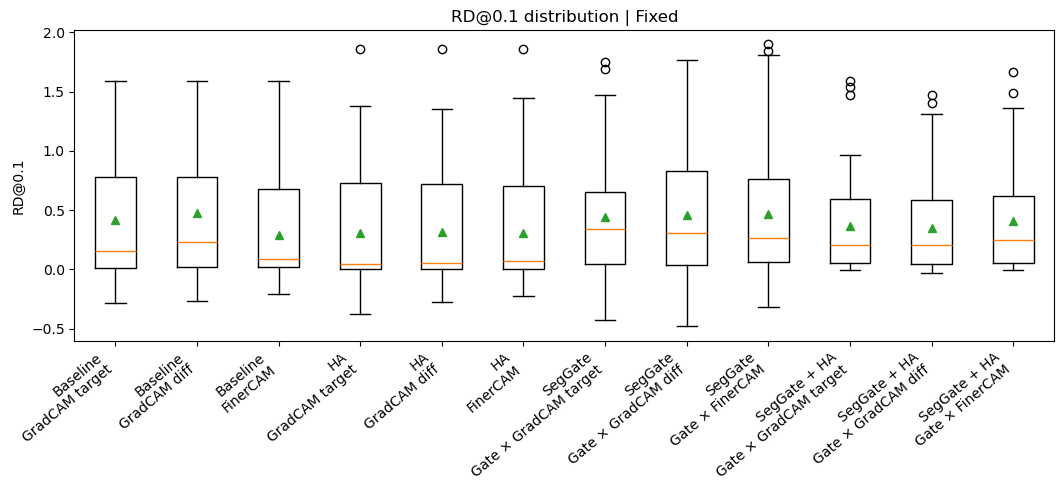

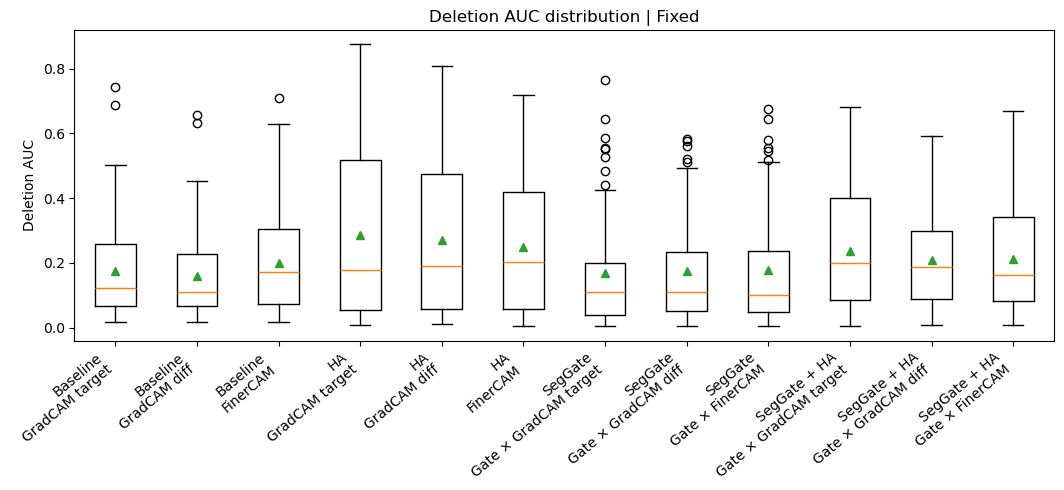

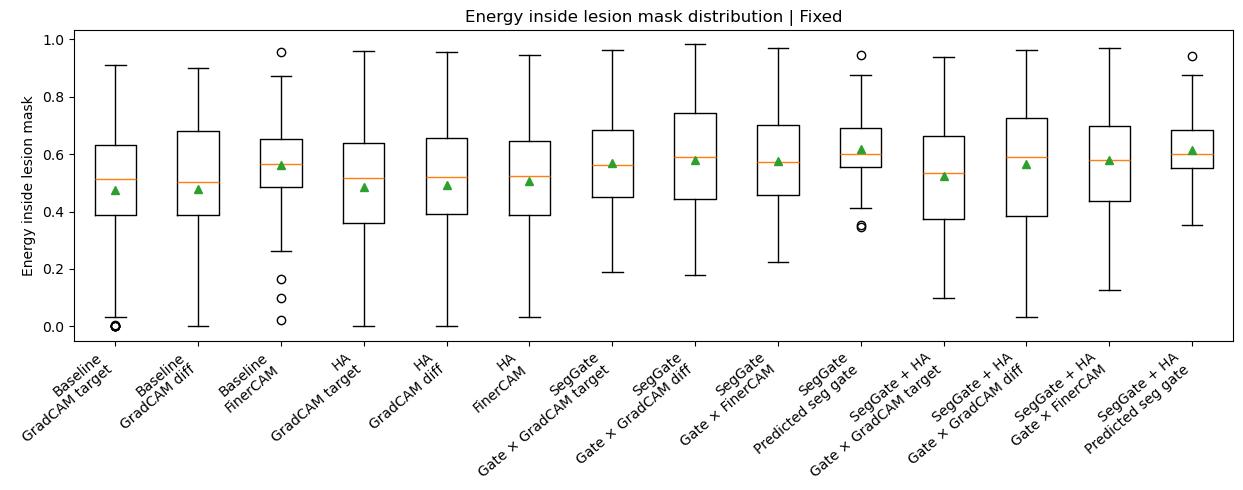

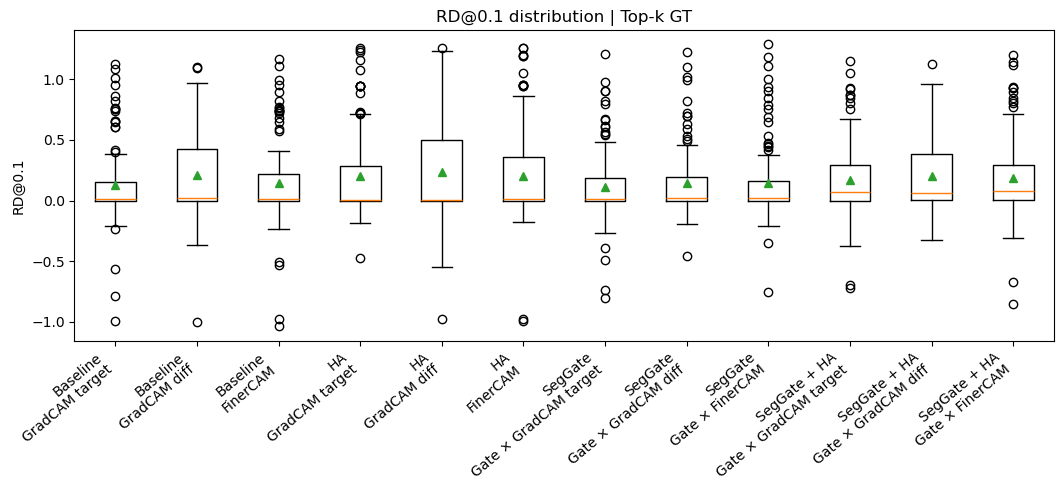

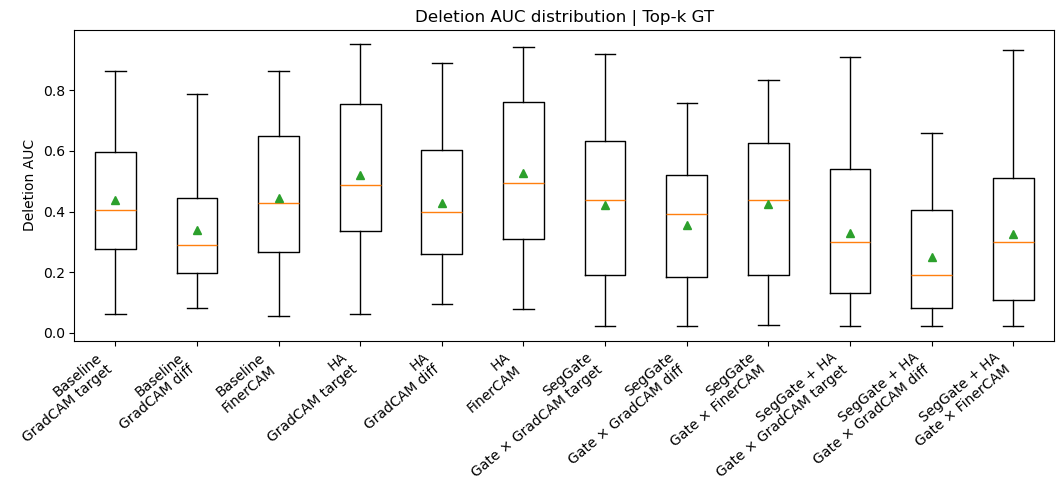

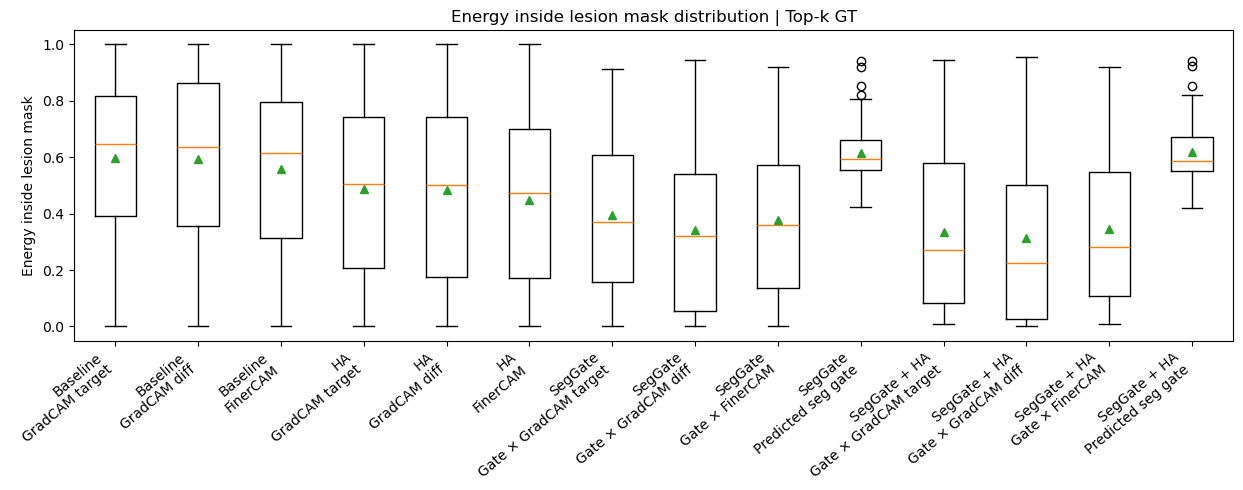

In [9]:
def plot_boxplot_groups(
    per_sample_df,
    metric_col,
    eval_name=None,
    compare_tag=None,
    experiments=None,
    methods=None,
    title=None,
    ylabel=None,
    max_groups_per_fig=14,
):
    if metric_col not in per_sample_df.columns:
        print(f"Metric not found: {metric_col}")
        return

    sub = per_sample_df.copy()

    if eval_name is not None:
        sub = sub[sub["eval_name"] == eval_name].copy()
    if compare_tag is not None:
        sub = sub[sub["compare_tag"] == compare_tag].copy()
    if experiments is not None:
        sub = sub[sub["experiment"].isin(experiments)].copy()
    if methods is not None:
        sub = sub[sub["method"].isin(methods)].copy()

    if sub.empty:
        print(f"No data for {metric_col} | eval={eval_name} | tag={compare_tag}")
        return

    sub["group"] = sub["experiment"] + "\n" + sub["method"].map(METHOD_DISPLAY).fillna(sub["method"])

    group_order_df = (
        sub[["group", "experiment_order", "method_order"]]
        .drop_duplicates()
        .sort_values(["experiment_order", "method_order"])
    )
    group_order = group_order_df["group"].tolist()

    chunks = [group_order[i:i + max_groups_per_fig] for i in range(0, len(group_order), max_groups_per_fig)]

    for chunk_idx, chunk in enumerate(chunks, start=1):
        data = []
        labels = []

        for group in chunk:
            vals = sub[sub["group"] == group][metric_col].dropna().values
            if len(vals) > 0:
                data.append(vals)
                labels.append(group)

        if not data:
            continue

        plt.figure(figsize=(max(10, 0.9 * len(labels)), 5))
        plt.boxplot(data, tick_labels=labels, showmeans=True)
        full_title = title or DISPLAY_NAMES.get(metric_col, metric_col)
        if eval_name is not None:
            full_title += f" | {eval_name}"
        if compare_tag is not None:
            full_title += f" | {compare_tag}"
        if len(chunks) > 1:
            full_title += f" | part {chunk_idx}/{len(chunks)}"

        plt.title(full_title)
        plt.ylabel(ylabel or DISPLAY_NAMES.get(metric_col, metric_col))
        plt.xticks(rotation=40, ha="right")
        plt.tight_layout()
        plt.show()


# Main robustness plots for every evaluation type.
for eval_name in sorted(all_per_sample["eval_name"].unique()):
    plot_boxplot_groups(
        all_per_sample,
        metric_col="rel_conf_average_relative_confidence_drop",
        eval_name=eval_name,
        methods=[
            "gradcam_target",
            "gradcam_diff",
            "finercam",
            "gate_weighted_gradcam_target",
            "gate_weighted_gradcam_diff",
            "gate_weighted_finercam",
        ],
        title="RD@0.1 distribution",
        ylabel="RD@0.1",
    )

    plot_boxplot_groups(
        all_per_sample,
        metric_col="del_auc",
        eval_name=eval_name,
        methods=[
            "gradcam_target",
            "gradcam_diff",
            "finercam",
            "gate_weighted_gradcam_target",
            "gate_weighted_gradcam_diff",
            "gate_weighted_finercam",
        ],
        title="Deletion AUC distribution",
        ylabel="Deletion AUC",
    )

    plot_boxplot_groups(
        all_per_sample,
        metric_col="mask_energy_inside",
        eval_name=eval_name,
        methods=[
            "gradcam_target",
            "gradcam_diff",
            "finercam",
            "gate_weighted_gradcam_target",
            "gate_weighted_gradcam_diff",
            "gate_weighted_finercam",
            "pred_seg_gate",
        ],
        title="Energy inside lesion mask distribution",
        ylabel="Energy inside lesion mask",
    )

## Compact slide table

In [10]:
# This table is usually easiest to copy into slides.
# It keeps only the core interpretability metrics and all available methods.

SLIDE_METRICS = [
    "rel_conf_average_relative_confidence_drop",
    "del_auc",
    "mask_energy_inside",
    "mask_pointing_game",
]

slide_table = make_compact_table(compact_summary, metrics=SLIDE_METRICS)

display(
    style_best_second(
        slide_table,
        SLIDE_METRICS,
        group_cols=["Evaluation", "Compare tag"],
    )
)

,Evaluation,Compare tag,Experiment,Method,N,RD@0.1 ↑,Deletion AUC ↓,Energy inside ↑,Pointing game ↑
0,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM target,70,0.418 ± 0.537,0.176 ± 0.158,0.476 ± 0.244,0.529 ± 0.503
1,Top-k GT,gt_topk_k3,Baseline,GradCAM target,100,0.128 ± 0.345,0.438 ± 0.214,0.596 ± 0.273,0.750 ± 0.435
2,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM reference,70,0.432 ± 0.711,0.243 ± 0.225,0.406 ± 0.332,0.457 ± 0.502
3,Top-k GT,gt_topk_k3,Baseline,GradCAM reference,100,-0.199 ± 0.356,0.627 ± 0.167,0.523 ± 0.236,0.690 ± 0.465
4,Fixed,fixed_MEL_vs_NV,Baseline,GradCAM diff,70,0.477 ± 0.561,0.161 ± 0.138,0.479 ± 0.249,0.514 ± 0.503
5,Top-k GT,gt_topk_k3,Baseline,GradCAM diff,100,0.209 ± 0.386,0.338 ± 0.182,0.592 ± 0.297,0.720 ± 0.451
6,Fixed,fixed_MEL_vs_NV,Baseline,FinerCAM,70,0.291 ± 0.376,0.201 ± 0.163,0.562 ± 0.171,0.729 ± 0.448
7,Top-k GT,gt_topk_k3,Baseline,FinerCAM,100,0.143 ± 0.367,0.445 ± 0.223,0.558 ± 0.287,0.770 ± 0.423
8,Fixed,fixed_MEL_vs_NV,HA,GradCAM target,70,0.306 ± 0.435,0.287 ± 0.278,0.486 ± 0.224,0.514 ± 0.503
9,Top-k GT,gt_topk_k3,HA,GradCAM target,100,0.200 ± 0.373,0.521 ± 0.244,0.488 ± 0.306,0.710 ± 0.456


## Quick textual interpretation

In [11]:
def print_best_by_metric(summary_df, eval_name=None, metrics=KEY_METRICS):
    sub = summary_df.copy()
    if eval_name is not None:
        sub = sub[sub["eval_name"] == eval_name].copy()

    for compare_tag in sorted(sub["compare_tag"].astype(str).unique()):
        tag_sub = sub[sub["compare_tag"].astype(str) == compare_tag].copy()
        if tag_sub.empty:
            continue

        print("\n" + "=" * 100)
        print(f"Compare tag: {compare_tag}")
        print("=" * 100)

        for metric in metrics:
            mean_col = f"{metric}_mean"
            std_col = f"{metric}_std"
            if mean_col not in tag_sub.columns:
                continue

            vals = tag_sub.dropna(subset=[mean_col]).copy()
            if vals.empty:
                continue

            ascending = metric in LOWER_IS_BETTER
            vals = vals.sort_values(mean_col, ascending=ascending)

            best = vals.iloc[0]
            second = vals.iloc[1] if len(vals) > 1 else None

            print(f"\n{DISPLAY_NAMES[metric]}")
            print(
                f"  Best:   {best['experiment']} | {best['method_display']} "
                f"= {mean_std_str(best[mean_col], best[std_col])}"
            )
            if second is not None:
                print(
                    f"  Second: {second['experiment']} | {second['method_display']} "
                    f"= {mean_std_str(second[mean_col], second[std_col])}"
                )

print_best_by_metric(compact_summary)


Compare tag: fixed_MEL_vs_NV

RD@0.1 ↑
  Best:   SegGate | Predicted seg gate = 0.623 ± 0.573
  Second: SegGate + HA | Predicted seg gate = 0.542 ± 0.505

Deletion AUC ↓
  Best:   SegGate | Predicted seg gate = 0.102 ± 0.122
  Second: SegGate + HA | Predicted seg gate = 0.134 ± 0.128

Energy inside ↑
  Best:   SegGate | Predicted seg gate = 0.618 ± 0.111
  Second: SegGate + HA | Predicted seg gate = 0.616 ± 0.112

Pointing game ↑
  Best:   SegGate + HA | Gate × FinerCAM = 0.743 ± 0.440
  Second: SegGate + HA | Gate × GradCAM diff = 0.729 ± 0.448

Compare tag: gt_topk_k3

RD@0.1 ↑
  Best:   HA | GradCAM diff = 0.237 ± 0.417
  Second: Baseline | GradCAM diff = 0.209 ± 0.386

Deletion AUC ↓
  Best:   SegGate + HA | Gate × GradCAM diff = 0.249 ± 0.184
  Second: SegGate + HA | Predicted seg gate = 0.315 ± 0.147

Energy inside ↑
  Best:   SegGate | Gate × GradCAM reference = 0.619 ± 0.184
  Second: SegGate + HA | Predicted seg gate = 0.618 ± 0.101

Pointing game ↑
  Best:   Baseline | Finer

# Main findings

## 1. Baseline remains strong, especially for Top k GT localization

In the **Top k GT** setting, the baseline performs surprisingly well. Baseline FinerCAM has the best pointing game score:

| Method | RD@0.1 ↑ | Deletion AUC ↓ | Energy inside ↑ | Pointing game ↑ |
|---|---:|---:|---:|---:|
| Baseline FinerCAM | 0.143 ± 0.367 | 0.445 ± 0.223 | 0.558 ± 0.287 | **0.770 ± 0.423** |
| Baseline GradCAM target | 0.128 ± 0.345 | 0.438 ± 0.214 | 0.596 ± 0.273 | 0.750 ± 0.435 |
| Baseline GradCAM diff | 0.209 ± 0.386 | 0.338 ± 0.182 | 0.592 ± 0.297 | 0.720 ± 0.451 |

**Interpretation:** The baseline already localizes reasonably well on the lesion in many cases. FinerCAM does not clearly dominate standard GradCAM in Top k GT, but it gives strong pointing game behavior.

---

## 2. HA + DAL gives the strongest class discriminative signal in Top k GT

For **Top k GT**, the strongest RD@0.1 comes from **HA + DAL with GradCAM diff**:

| Method | RD@0.1 ↑ | Deletion AUC ↓ | Energy inside ↑ | Pointing game ↑ |
|---|---:|---:|---:|---:|
| HA + DAL GradCAM diff | **0.332 ± 0.430** | 0.404 ± 0.216 | 0.488 ± 0.343 | 0.700 ± 0.461 |
| DAL GradCAM diff | 0.299 ± 0.473 | 0.353 ± 0.210 | 0.543 ± 0.320 | 0.730 ± 0.446 |
| HA FinerCAM | 0.202 ± 0.419 | 0.529 ± 0.254 | 0.447 ± 0.303 | 0.720 ± 0.451 |

**Interpretation:** HA + DAL seems useful when the goal is class contrast. The strongest result is not FinerCAM itself, but the **difference based GradCAM map**. This suggests that class discriminative training helps the model separate class evidence, but the benefit is most visible in difference style maps.

---

## 3. SegGate strongly improves lesion focused quantitative metrics

In the **fixed MEL vs NV** setting, SegGate gives the strongest overall quantitative results. The predicted segmentation gate itself is strongest for RD@0.1, deletion AUC, energy inside, mask IoU, and mask Dice:

| Method | RD@0.1 ↑ | Deletion AUC ↓ | Energy inside ↑ | Pointing game ↑ |
|---|---:|---:|---:|---:|
| SegGate predicted seg gate | **0.623 ± 0.573** | **0.102 ± 0.122** | **0.618 ± 0.111** | 0.386 ± 0.490 |
| SegGate Gate × FinerCAM | 0.463 ± 0.505 | 0.179 ± 0.182 | 0.575 ± 0.176 | 0.643 ± 0.483 |
| SegGate Gate × GradCAM diff | 0.458 ± 0.482 | 0.175 ± 0.166 | 0.578 ± 0.205 | 0.686 ± 0.468 |

**Interpretation:** SegGate makes the CAMs much more lesion focused. However, the predicted segmentation gate is not a class explanation by itself. It is mainly a lesion localization map. Therefore, the more relevant methods for explainability are **Gate × GradCAM target**, **Gate × GradCAM diff**, and **Gate × FinerCAM**.

---

## 4. SegGate + HA does not clearly improve over SegGate

SegGate + HA gives the best pointing game result in the **fixed MEL vs NV** setting:

| Method | RD@0.1 ↑ | Deletion AUC ↓ | Energy inside ↑ | Pointing game ↑ |
|---|---:|---:|---:|---:|
| SegGate + HA Gate × FinerCAM | 0.404 ± 0.412 | 0.213 ± 0.169 | 0.579 ± 0.195 | **0.743 ± 0.440** |
| SegGate + HA Gate × GradCAM diff | 0.350 ± 0.384 | 0.210 ± 0.157 | 0.565 ± 0.222 | 0.729 ± 0.448 |
| SegGate predicted seg gate | 0.623 ± 0.573 | 0.102 ± 0.122 | 0.618 ± 0.111 | 0.386 ± 0.490 |

**Interpretation:** Adding HA to SegGate may improve the location of the strongest activation point, especially for Gate × FinerCAM. But it does not improve the main confidence based metrics compared with SegGate alone. Therefore, SegGate + HA is interesting but not clearly superior.

---

# Recommended compact table to show supervisor

I would show this as the main summary:

| Experiment | Best representative method | Main strength | Main limitation |
|---|---|---|---|
| **Baseline** | FinerCAM / GradCAM diff | Strong reference, good Top k GT pointing game | Not consistently class distinctive |
| **HA + DAL** | GradCAM diff | Best Top k GT RD@0.1 | Localization not better than baseline |
| **SegGate** | Gate × FinerCAM / Gate × GradCAM diff | Best lesion focused behavior in MEL vs NV | Partly artificial because gate enforces lesion focus |
| **SegGate + HA** | Gate × FinerCAM | Best fixed MEL vs NV pointing game | Does not clearly beat SegGate overall |

---

# Short conclusion

The results suggest two different effects:

**HA + DAL improves class discriminative behavior**, especially for Top k GT where GradCAM diff achieves the best RD@0.1.

**SegGate improves lesion localization**, especially in the fixed MEL vs NV setting, where gate weighted maps become much more focused on the lesion.

However, the best lesion localization often comes from the predicted segmentation gate itself. This should be interpreted carefully because it is not a class specific explanation. For clinician facing visualization, the most relevant output is therefore not the raw segmentation gate, but **Gate × FinerCAM** or **Gate × GradCAM diff**, because these combine lesion focus with class related CAM information.

My recommendation is to present **Baseline vs HA + DAL vs SegGate** as the main comparison, and keep **SegGate + HA** as an additional experiment showing that HA does not clearly improve the SegGate setup.